# Transform global zarr dataset to cloud optimized geotiff

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import xyzservices as xyz
import coiled
from global_snowmelt_runoff_onset.config import Config, Tile
import geopandas as gpd
import fsspec
import azure.storage.blob
import io
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import rasterio
#from osgeo import gdal
#gdal.__version__
import dask.distributed

In [8]:
config = Config('config/global_config_v9.txt')

SAS token is valid until 2025-10-21 18:55 UTC (168.0 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
season

In [ ]:
cluster = coiled.Cluster(idle_timeout="10 minutes",
                         #shutdown_on_close=False,
                         #wait_for_workers=True,
                         #n_workers=[41,170], # 170
                         #n_workers=[31,86],
                         n_workers=2,
                         #n_workers=8,
                         #n_workers=10,
                         worker_memory="256 GB", #coiled.list_instance_types(backend="azure")
                         #worker_options={"nthreads": 1},
                         #worker_options={"nthreads": 32},# 16 8 4 oversubscribe?
                         #scheduler_memory="256 GB",
                         #scheduler_memory="128 GB",
                         spot_policy="spot", # spot usually
                         #software="sar_snowmelt_timing",
                         environ={"GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR"},
                         #container="mcr.microsoft.com/planetary-computer/python:latest",
                         workspace="uwtacolab",
                         
                         )

client = cluster.get_client()

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                                ╷                                             │
│   Package                      │ Note                                        │
│ ╶──────────────────────────────┼───────────────────────────────────────────╴ │
│   global_snowmelt_runoff_onset │ Wheel built from                            │
│                                │ ~/repos/global_snowmelt_runoff_onset        │
│                                ╵                                             │
╰──────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────── Not Synced with Cluster ───────────────────────────╮
│             ╷                                                    ╷           │
│   Package   │ Error                                              │ Level     │
│ ╶───────────┼────────────────────────────────────────────────────┼─────────╴ │
│   rioxarray │ Pip check had the following issues that need       │ Warning   │
│             │ resolving:                                         │           │
│             │ rioxarray 0.19.0 has requirement rasterio>=1.4.3,  │           │
│             │ but you have rasterio 1.3.9.                       │           │
│             ╵                                                    ╵           │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

/home/eric/miniconda3/envs/zarr_to_cog_global_snowmelt_runoff_onset/lib/python3.12/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/home/eric/miniconda3/envs/zarr_to_cog_global_snowmelt_runoff_onset/lib/python3.12/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/home/eric/miniconda3/envs/zarr_to_cog_global_snowmelt_runoff_onset/lib/python3.12/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/home/eric/miniconda3/envs/zarr_to

In [9]:
client.restart()

In [10]:
def convert_zarr_region_to_cog(region_name,region_bounds):
    """
    Convert a region of a Zarr dataset to a COG.
    """
    
    try:
        import os
        import xarray as xr
        # Open the Zarr dataset

        # gdal.SetConfigOption('AZURE_STORAGE_ACCOUNT', config.azure_blob_fs.account_name)
        # gdal.SetConfigOption('AZURE_STORAGE_SAS_TOKEN', config.azure_blob_fs.credential)
        os.environ['AZURE_STORAGE_ACCOUNT'] = config.azure_blob_fs.account_name
        os.environ['AZURE_STORAGE_SAS_TOKEN'] = config.azure_blob_fs.credential

        ds = xr.open_zarr(config.global_runoff_store, 
                        consolidated=True, 
                        decode_coords='all',
                        )
        
        # Select the region
        region_da = ds['temporal_resolution_median'].sel(latitude=slice(region_bounds['lat_max'], region_bounds['lat_min']), 
                        longitude=slice(region_bounds['lon_min'], region_bounds['lon_max']))
        
        scale_factor = 0.1
        add_offset = 0.0
        region_da.encoding["Scale"] = scale_factor
        region_da.encoding["Offset"] = add_offset
        
        
        region_da = region_da*(1/scale_factor)
        
        # if MAD is 0 or less, or greater than 300, set to nodata
        region_da = region_da.where((region_da > 0) & (region_da <= 300), -9999)
        
        region_da = region_da.rio.write_nodata(-9999)
        region_da = region_da.astype('int16')
        

        #region_da = region_da.persist()
        #region_da = region_da.rio.reproject("ESRI:54030",resolution=80,resampling=rasterio.enums.Resampling.average,nodata=-9999,dtype='int16')
        
        # Convert to COG
        with config.azure_blob_fs.open(f"snowmelt/snowmelt_runoff_onset/global_tifs/{config.version}/res/wgs84/{region_name}_res.tif", mode="wb") as f:
            region_da.rio.to_raster(f,
                                driver="COG",
                                dtype="int16",
                                tiled=True,
                                profile_kwargs={"BIGTIFF": "YES"},
                                #windowed=True,
                                BIGTIFF="YES",
                                storage_options={
                                    "AZURE_STORAGE_ACCOUNT": config.azure_blob_fs.account_name,
                                    "AZURE_STORAGE_SAS_TOKEN": config.azure_blob_fs.credential,
                                },
                            )
            
        return region_name, "success"

    except Exception as e:
        return region_name, f"error: {e}"

/tmp/ipykernel_3959124/2279797061.py:22: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  regions_gdf['geometry'] = regions_gdf.apply(lambda row: shapely.box(row['lon_min'], row['lat_min'], row['lon_max'], row['lat_max']), axis=1)


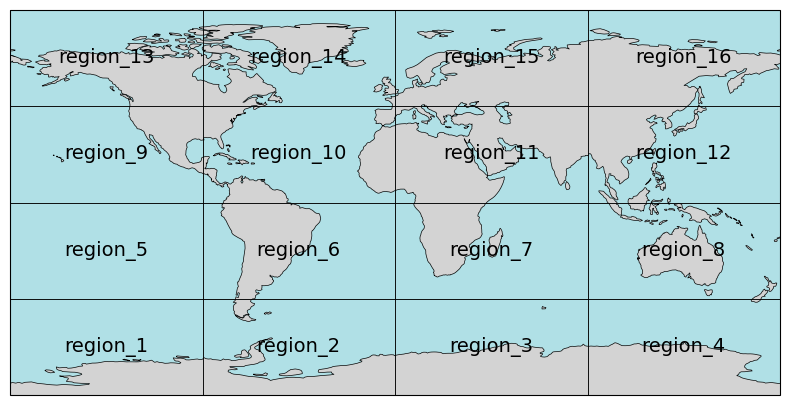

In [11]:
# break globe into regions, with latitude breaks at -90, -45, 0, 45, 90 and longitude breaks at -180, -90, 0, 90, 180
regions = {
    'region_1': {'lat_min': -90, 'lat_max': -45, 'lon_min': -180, 'lon_max': -90},
    'region_2': {'lat_min': -90, 'lat_max': -45, 'lon_min': -90, 'lon_max': 0},
    'region_3': {'lat_min': -90, 'lat_max': -45, 'lon_min': 0, 'lon_max': 90},
    'region_4': {'lat_min': -90, 'lat_max': -45, 'lon_min': 90, 'lon_max': 180},
    'region_5': {'lat_min': -45, 'lat_max': 0, 'lon_min': -180, 'lon_max': -90},
    'region_6': {'lat_min': -45, 'lat_max': 0, 'lon_min': -90, 'lon_max': 0},
    'region_7': {'lat_min': -45, 'lat_max': 0, 'lon_min': 0, 'lon_max': 90},
    'region_8': {'lat_min': -45, 'lat_max': 0, 'lon_min': 90, 'lon_max': 180},
    'region_9': {'lat_min': 0, 'lat_max': 45, 'lon_min': -180, 'lon_max': -90},
    'region_10': {'lat_min': 0, 'lat_max': 45, 'lon_min': -90, 'lon_max': 0},
    'region_11': {'lat_min': 0, 'lat_max': 45, 'lon_min': 0, 'lon_max': 90},
    'region_12': {'lat_min': 0, 'lat_max': 45, 'lon_min': 90, 'lon_max': 180},
    'region_13': {'lat_min': 45, 'lat_max': 90, 'lon_min': -180, 'lon_max': -90},
    'region_14': {'lat_min': 45, 'lat_max': 90, 'lon_min': -90, 'lon_max': 0},
    'region_15': {'lat_min': 45, 'lat_max': 90, 'lon_min': 0, 'lon_max': 90},
    'region_16': {'lat_min': 45, 'lat_max': 90, 'lon_min': 90, 'lon_max': 180},
}

regions_gdf = gpd.GeoDataFrame.from_dict(regions, orient='index')
regions_gdf['geometry'] = regions_gdf.apply(lambda row: shapely.box(row['lon_min'], row['lat_min'], row['lon_max'], row['lat_max']), axis=1)


fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})

regions_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5, transform=ccrs.PlateCarree())
# label the regions
for region_name, region_bounds in regions.items():
    ax.text((region_bounds['lon_min'] + region_bounds['lon_max']) / 2, 
            (region_bounds['lat_min'] + region_bounds['lat_max']) / 2, 
            region_name, 
            fontsize=14, 
            ha='center', 
            va='center', 
            transform=ccrs.PlateCarree())
    
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="powderblue") 
ax.coastlines(resolution='110m', linewidth=0.5, edgecolor='black')

In [12]:
# # test just region 1
# region_name = 'region_1'
# region_bounds = regions[region_name]
# future = client.submit(convert_zarr_region_to_cog, region_name, region_bounds)
# future

# futures = []
# for region_name, region in regions.items():
#     future = client.submit(convert_zarr_region_to_cog, region_name, region)
#     futures.append(future)
    
# instead submit 4 at a time, wait for them to finish, then submit 4 more. can use as_completed
batch_size = 2
futures = []

for batch in range(0, len(regions), batch_size):
    
    futures = []
    
    for region_name, region_bounds in list(regions.items())[batch:batch+batch_size]:
        future = client.submit(convert_zarr_region_to_cog, region_name, region_bounds)
        futures.append(future)

    for future,result in dask.distributed.as_completed(futures, with_results=True, raise_errors=False):
        print(f"Finished {future.key} with result: {result}")
        
    client.restart()

Finished convert_zarr_region_to_cog-6121cefc22e8fee202f76a65025cb010 with result: ('region_1', 'success')
Finished convert_zarr_region_to_cog-f2cd5bf6bcadb14db671714102c87011 with result: ('region_2', 'success')
Finished convert_zarr_region_to_cog-94c1488192afa739109eac1191ab20fc with result: ('region_4', 'success')
Finished convert_zarr_region_to_cog-3ed2735c46cc2055ae551a75ad14c7b0 with result: ('region_3', 'success')
Finished convert_zarr_region_to_cog-aa0beac6f40c1b7712514eea00b58f31 with result: ('region_6', 'success')
Finished convert_zarr_region_to_cog-f3e4344db7412b7a86ebabef59c9fffd with result: ('region_5', 'success')
Finished convert_zarr_region_to_cog-cdd4bc80b52691f701c00096e3a0d824 with result: ('region_8', 'success')
Finished convert_zarr_region_to_cog-743c806afbfb159ecf735ee8a0c0774b with result: ('region_7', 'success')
Finished convert_zarr_region_to_cog-74e6c1aca1c4b63a87eed1e13bb3a4bd with result: ('region_9', 'success')
Finished convert_zarr_region_to_cog-1540174f86

In [13]:
client.restart()

In [14]:
def reproject_cog_to_robinson(region_name):
    """
    Reproject an existing COG to Robinson projection (ESRI:54030).
    """
    import subprocess
    import os
    
    # Set Azure credentials
    os.environ['AZURE_STORAGE_ACCOUNT'] = config.azure_blob_fs.account_name
    os.environ['AZURE_STORAGE_SAS_TOKEN'] = config.azure_blob_fs.credential
    os.environ['CPL_VSIL_USE_TEMP_FILE_FOR_RANDOM_WRITE'] = 'YES'  # Enable temp files for Azure writes

    
    # Input and output paths
    input_path = f"/vsiaz/snowmelt/snowmelt_runoff_onset/global_tifs/{config.version}/res/wgs84/{region_name}_res.tif"
    temp_path = f"/vsiaz/snowmelt/snowmelt_runoff_onset/global_tifs/{config.version}/res/robinson/{region_name}_temp.tif"
    output_path = f"/vsiaz/snowmelt/snowmelt_runoff_onset/global_tifs/{config.version}/res/robinson/{region_name}_res_robinson.tif"
    
    try:
        print(f"Reprojecting {region_name} to Robinson projection...")
        
        # Use gdalwarp to reproject and create COG
        warp_cmd = [
            'gdalwarp',
            '-s_srs', 'EPSG:4326',  
            '-t_srs', 'ESRI:54030',  # Robinson projection
            '-tr', '80', '80',
            '-of', 'COG',
            '-co', 'BIGTIFF=YES',
            '-co', 'TILED=YES',
            '-co', 'BLOCKSIZE=512',
            '-co', 'COMPRESS=DEFLATE',
            '-co', 'OVERVIEW_RESAMPLING=AVERAGE',
            '-co', 'PREDICTOR=2',
            '-r', 'average',  # Resampling method
            '-ot', 'Int16',
            '-dstnodata', '-9999',
            '-wo', 'SKIP_NOSOURCE=YES',
            '-multi',
            input_path,
            temp_path
        ]
        
        result = subprocess.run(warp_cmd, capture_output=True, text=True)
        
        if result.returncode != 0:
            return f"Reprojection failed for {region_name}: {result.stderr}"
        
        # Use gdal_translate to add scale and offset metadata
        translate_cmd = [
            'gdal_translate',
            '-of', 'COG',
            '-co', 'BIGTIFF=YES',
            '-co', 'TILED=YES',
            '-co', 'BLOCKSIZE=512',
            '-co', 'COMPRESS=DEFLATE',
            '-co', 'OVERVIEW_RESAMPLING=AVERAGE',
            '-co', 'PREDICTOR=2',
            '-ot', 'Int16',
            '-a_scale', '0.1',  # Apply scale factor
            '-a_offset', '0.0', # Apply add offset
            temp_path,
            output_path
        ]
        
        result = subprocess.run(translate_cmd, capture_output=True, text=True)
        
        if result.returncode != 0:
            return f"Adding scale/offset failed for {region_name}: {result.stderr}"

        
        # now delete the temp file
        try:
            config.azure_blob_fs.rm(f"snowmelt/snowmelt_runoff_onset/global_tifs/{config.version}/res/robinson/{region_name}_temp.tif")
            print(f"Deleted temporary file for {region_name}")
            return f"Successfully reprojected {region_name}"
        except Exception as e:
            return f"Reprojected {region_name}, but failed to delete temp file: {e}"
            
    except Exception as e:
        return f"Error occurred while reprojecting {region_name}: {e}"

In [15]:
batch_size = 2

for batch in range(0, len(regions), batch_size):
    futures = []
    
    # Submit a batch of tasks
    for region_name in list(regions.keys())[batch:batch+batch_size]:
        future = client.submit(reproject_cog_to_robinson, region_name)
        futures.append(future)
        print(f"Submitted reprojection for {region_name}")

    # Monitor progress for this batch
    for future, result in dask.distributed.as_completed(futures, with_results=True, raise_errors=False):
        print(f"{result}")
        
    print(f"Completed batch {batch//batch_size + 1} of {len(regions)//batch_size + (1 if len(regions) % batch_size else 0)}")
    client.restart()

Submitted reprojection for region_1
Submitted reprojection for region_2
Successfully reprojected region_2
Successfully reprojected region_1
Completed batch 1 of 8
Submitted reprojection for region_3
Submitted reprojection for region_4
Successfully reprojected region_3
Successfully reprojected region_4
Completed batch 2 of 8
Submitted reprojection for region_5
Submitted reprojection for region_6
Successfully reprojected region_6
Successfully reprojected region_5
Completed batch 3 of 8
Submitted reprojection for region_7
Submitted reprojection for region_8
Successfully reprojected region_7
Successfully reprojected region_8
Completed batch 4 of 8
Submitted reprojection for region_9
Submitted reprojection for region_10
Reprojection failed for region_10: Warning 6: driver COG does not support creation option TILED
ERROR 1: PUT of /vsiaz/snowmelt/snowmelt_runoff_onset/global_tifs/v9/res/robinson/region_10_temp.tif.tmp.tif failed
ERROR 3: region_10_temp.tif.tmp.tif: I/O error
ERROR 4: Unable 

In [16]:
client.restart()

In [ ]:
os.environ['AZURE_STORAGE_ACCOUNT'] = config.azure_blob_fs.account_name
os.environ['AZURE_STORAGE_SAS_TOKEN'] = config.azure_blob_fs.credential

for region_name in regions.keys():
    print(f'{region_name}: ')
    print(f'wgs84...')
    !gdalinfo /vsiaz/snowmelt/snowmelt_runoff_onset/global_tifs/{config.version}/mad/wgs84/{region_name}_mad.tif | grep "Pixel Size"
    !gdalinfo /vsiaz/snowmelt/snowmelt_runoff_onset/global_tifs/{config.version}/mad/wgs84/{region_name}_mad.tif | grep "Scale"
    print(f'robinson...')
    !gdalinfo /vsiaz/snowmelt/snowmelt_runoff_onset/global_tifs/{config.version}/mad/robinson/{region_name}_mad_robinson.tif | grep "Pixel Size"
    !gdalinfo /vsiaz/snowmelt/snowmelt_runoff_onset/global_tifs/{config.version}/mad/robinson/{region_name}_mad_robinson.tif | grep "Scale"

In [19]:
client.close()

In [20]:
config.azure_blob_fs.download(f"snowmelt/snowmelt_runoff_onset/global_tifs/{config.version}/res/robinson/", "/mnt/c/Users/elgag/OneDrive - UW/QGIS/runoff_onset_analysis_global_mountain_range_figs/runoff_onset_res/", recursive=True)

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [ ]:
!ls -lha "/mnt/c/Users/elgag/OneDrive - UW/QGIS/runoff_onset_analysis_global_mountain_range_figs/runoff_onset_mad/robinson/"